In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Week 4 — Exploratory Data Analysis

**Welltory COVID-19 & Wearables Dataset**

*Praful Chunchu — AIPI 503*

## Question & Approach

- The question this notebook explores is: how does sleep duration and BMI relate to RMSSD?
- The reason I chose RMSSD as the feature in interest is due it being one of the best HRV marker of parasympathetic recovery
- The 3 CSV files I've chosen for this are sleep.csv, hrv_measurements.csv, and participants.csv

In [3]:
# Checking all the files
data_sets = "data/week4_datasets"
data_files = os.listdir(data_sets)
data_files

['scales_description.csv',
 'participants.csv',
 'wearables.csv',
 'blood_pressure.csv',
 'surveys.csv',
 'heart_rate.csv',
 'weather.csv',
 '.ipynb_checkpoints',
 'hrv_measurements.csv',
 'sleep.csv']

In [5]:
# Load and Inspect

- **hrv_measurements.csv** — contains RMSSD, the primary variable of interest.
- **sleep.csv** — contains objective sleep metrics from wearables, needed as the predictor.
- **participants.csv** — provides per-user confounders (age, gender, weight) that are known to influence HRV.

In [6]:
participants_df = pd.read_csv('data/week4_datasets/participants.csv')
hrv_df = pd.read_csv('data/week4_datasets/hrv_measurements.csv')
sleep_df = pd.read_csv('data/week4_datasets/sleep.csv')

### Exploring Participants dataset

In [8]:
participants_df.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


In [9]:
print("Participants Data Structure")
print("---------------")
print(f"Dimensions: {participants_df.shape}")
print(f"\nData Types:\n{participants_df.dtypes}")
print(f"\nMissing Values:\n{participants_df.isnull().sum()}")


Participants Data Structure
---------------
Dimensions: (185, 8)

Data Types:
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object

Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


**Initial Observations (Participants.csv)**

- 185 users, 8 columns.  Mostly categorical, while `height` and `weight` are numeric.  I noticed that the `height` is in cm
and `symptoms_onset` as an object type, though it represents a date
-There are null values in this dataset, however, the features that are null, except for `height` (2 null values), are of no interest to us because we will not be focusing on `city`, `country`, and `symptoms_onset`
- `Symptoms_onset` null values may reflect users who couldn't recall exact date or chose not to disclose the onset of their sickness.  Also,
not used in our scope of analysis.
- We will impute the 2 missing `height` values later with the median value

In [11]:
# Will convert symptoms_onset from object to datetime:

participants_df['symptoms_onset'] = pd.to_datetime(participants_df['symptoms_onset'])

print(f"\nData Types:\n{participants_df.dtypes}")


Data Types:
user_code                 object
gender                    object
age_range                 object
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object


### Exploring HRV Observations

In [12]:
hrv_df.head()

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


In [13]:
print("HRV Measurements Data Structure")
print("---------------")
print(f"Dimensions: {hrv_df.shape}")
# print(f"\nData Types:\n{hrv_df.dtypes}")
print(f"\nMissing Values:\n{hrv_df.isnull().sum()}")


# Converting date related features to datetime from object

hrv_df['measurement_datetime'] = pd.to_datetime(hrv_df['measurement_datetime'])

print(f"\nData Types:\n{hrv_df.dtypes}")

HRV Measurements Data Structure
---------------
Dimensions: (3245, 22)

Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn                       0
rmssd                      0
pnn50                      0
mode                       0
amo                        0
lf                         0
hf                         0
vlf                        0
lfhf                       0
total_power                0
how_feel                   0
how_mood                   0
how_sleep               1779
tags                    1044
rr_data                    0
dtype: int64

Data Types:
user_code                       object
rr_code                         object
measurement_datetime    datetime64[ns]
time_of_day                     object
bpm                              int64
meanrr                         float64
mxdmn         

Initial Observations - HRV:

- 3,245 measurements across 22 columns.
- SDNN, RMSSD, pNN50, LF, HF, VLF, etc seem to be redundant with RMSSD for this specific analysis.
- RMSSD was selected as the single focus metric because it is the most established marker of parasympathetic activity 
and captures the recovery dimension most relevant to sleep.
- `how_sleep` is missing for about 1779 rows more than half - I'm ignoring it because this is subjective to each user's feel of the sleep
- `tags` and `rr_data` are unstructured/raw and out of scope for this project
- Users can have multiple measurements per day so I'll need to aggregate to daily before joining with sleep dataset later

In [14]:
# Checking the values for how_feel and how_mood to see if we need encode them later or leave as is
print(hrv_df['how_feel'].value_counts(dropna=False))
print(hrv_df['how_mood'].value_counts(dropna=False))
print(hrv_df['how_sleep'].value_counts(dropna=False))

how_feel
 0    1975
-1     857
 1     237
-2     124
 2      52
Name: count, dtype: int64
how_mood
 0    2335
-1     471
 1     272
-2      96
 2      71
Name: count, dtype: int64
how_sleep
 NaN    1779
 0.0     967
-1.0     238
 1.0     180
-2.0      50
 2.0      31
Name: count, dtype: int64


**Observation:** `how_feel` and `how_mood` use a -2 to +2 Likert scale — 0 is a real "neutral" answer, not a sentinel null. `how_sleep` has ~55% missing (users measure HRV multiple times a day but only rate sleep once). Not used in this analysis: subjective scores overlap conceptually with objective sleep metrics that are already available.

### Sleep Dataset Observation

In [15]:
sleep_df.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


In [16]:
print("Sleep Data Structure")
print("---------------")
print(f"Dimensions: {sleep_df.shape}")
# print(f"\nData Types:\n{sleep_df.dtypes}")
print(f"\nMissing Values:\n{sleep_df.isnull().sum()}")

sleep_df['day'] = pd.to_datetime(sleep_df['day'])
sleep_df['sleep_begin'] = pd.to_datetime(sleep_df['sleep_begin'])
sleep_df['sleep_end'] = pd.to_datetime(sleep_df['sleep_end'])

print(f"\nData Types:\n{sleep_df.dtypes}")

Sleep Data Structure
---------------
Dimensions: (425, 12)

Missing Values:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64

Data Types:
user_code                       object
day                     datetime64[ns]
sleep_begin             datetime64[ns]
sleep_end               datetime64[ns]
sleep_duration                 float64
sleep_awake_duration           float64
sleep_rem_duration             float64
sleep_light_duration           float64
sleep_deep_duration            float64
pulse_min                      float64
pulse_max                      float64
pulse_average                  float64
dtype: object


In [17]:
sleep_df.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


### Initial Observations:

- 425 rows and 12 columns, One row per user per night.
- Lots of null rows, these will be dropped as imputing this will not provide any insights.  Also it doesn't seem, that the rows being null provide any insights either.
- Thus, `sleep_duration` will be used.  However, it seems this variable is in seconds, will convert to hours for better interpretability

### Descriptive Statistics

In [18]:
# Descriptive Data analysis

# Descriptive Statistics
print("\nDescriptive Statistics")
participants_numeric_columns = participants_df.select_dtypes(include=[np.number]).columns

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(participants_df[participants_numeric_columns].skew())
print(participants_df[participants_numeric_columns].kurt())


Descriptive Statistics

Distribution Measures:
------------------------
height    2.910275
weight    0.865345
dtype: float64
height    17.552808
weight     0.891368
dtype: float64


In [19]:
# Without the np.number we were getting values for the datetime as well which we do not need for descriptive analysis
participants_df.describe(include=[np.number])

,height,weight
count,183.000000,185.000000
mean,169.976393,77.927757
std,12.400103,19.552541
min,132.080000,43.500000
25%,163.500000,63.500000
50%,168.000000,74.344000
75%,174.500000,90.537000
max,250.000000,154.221000


In [20]:
# Descriptive Statistics for hrv_measurements
print("\nDescriptive Statistics")
numeric_hrv_df = hrv_df.select_dtypes(include=[np.number]).columns

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(hrv_df[numeric_hrv_df].skew())
print(hrv_df[numeric_hrv_df].kurt())


Descriptive Statistics

Distribution Measures:
------------------------
bpm            0.482403
meanrr         0.334116
mxdmn          1.693464
sdnn           1.719168
rmssd          2.658394
pnn50          1.405382
mode           0.387824
amo            0.533381
lf             3.802072
hf             5.339414
vlf            6.048862
lfhf           7.984958
total_power    3.791925
how_feel      -0.009404
how_mood      -0.084638
how_sleep     -0.124948
dtype: float64
bpm             0.047671
meanrr         -0.152961
mxdmn           3.661775
sdnn            4.169468
rmssd           9.035253
pnn50           2.017637
mode           -0.262343
amo             0.119199
lf             19.731684
hf             35.995663
vlf            76.788257
lfhf           93.351348
total_power    18.237076
how_feel        1.157584
how_mood        2.603627
how_sleep       1.554129
dtype: float64


In [21]:
hrv_df.describe(include=[np.number])

,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep
count,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,1466.000000
mean,73.257935,839.600366,0.184635,52.489218,52.814196,20.615609,0.837465,46.788290,927.038213,1125.041294,578.229892,2.397769,2630.309399,-0.235439,-0.076733,-0.065484
std,12.201088,137.420367,0.107456,29.369506,39.353213,18.588156,0.144769,16.418873,1455.424089,2490.540413,876.679652,5.750760,3912.247496,0.706262,0.655032,0.708656
min,44.000000,477.730000,0.030000,9.515000,6.340000,0.000000,0.475000,12.000000,2.000000,4.000000,1.000000,0.032000,44.000000,-2.000000,-2.000000,-2.000000
25%,65.000000,742.490000,0.110000,32.585000,28.985000,6.060000,0.725000,35.000000,151.000000,158.000000,116.000000,0.399000,620.000000,-1.000000,0.000000,0.000000
50%,72.000000,829.100000,0.160000,46.919000,42.869000,16.160000,0.825000,45.000000,423.000000,380.000000,293.000000,0.862000,1387.000000,0.000000,0.000000,0.000000
75%,81.000000,925.933000,0.220000,64.406000,62.485000,29.290000,0.925000,57.000000,1059.000000,993.000000,693.000000,1.966000,2906.000000,0.000000,0.000000,0.000000
max,125.000000,1346.740000,0.790000,206.631000,310.800000,91.920000,1.325000,98.000000,15522.000000,33490.000000,18468.000000,105.625000,41118.000000,2.000000,2.000000,2.000000


**HRV:** RMSSD is right-skewed (mean 52.8 > median 42.9) with high kurtosis — expect a long right tail (extreme high-HRV readings from athletic/young individuals). This informs the aggregation choice: **median over mean** when collapsing to daily grain.

In [22]:
# Descriptive Statistics for sleep df
print("\nDescriptive Statistics")
numeric_sleep_df = sleep_df.select_dtypes(include=[np.number]).columns

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(sleep_df[numeric_sleep_df].skew())
print(sleep_df[numeric_sleep_df].kurt())


Descriptive Statistics

Distribution Measures:
------------------------
sleep_duration         -0.564909
sleep_awake_duration    1.162801
sleep_rem_duration     -0.845230
sleep_light_duration   -0.877082
sleep_deep_duration     0.051316
pulse_min               3.340275
pulse_max              -1.289063
pulse_average           2.846251
dtype: float64
sleep_duration           0.827471
sleep_awake_duration     2.865854
sleep_rem_duration       0.304322
sleep_light_duration    -0.870222
sleep_deep_duration     -0.461251
pulse_min               12.078993
pulse_max                2.473699
pulse_average            9.394066
dtype: float64


In [23]:
sleep_df.describe(include=[np.number])

,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
count,425.000000,9.000000,7.000000,27.000000,14.000000,15.000000,15.000000,15.000000
mean,25699.731765,2733.333333,6518.571429,14514.740741,4280.285714,60.533333,89.866667,68.880733
std,7773.805470,671.900290,2081.613385,8078.126290,2089.766547,12.844491,10.541528,10.947268
min,930.000000,1740.000000,2820.000000,300.000000,480.000000,52.000000,62.000000,59.444000
25%,21857.000000,2460.000000,5730.000000,7995.000000,2797.500000,54.500000,85.000000,63.393000
50%,26041.000000,2490.000000,6240.000000,17340.000000,4230.000000,58.000000,93.000000,65.857000
75%,30600.000000,2790.000000,8190.000000,20340.000000,5550.000000,60.000000,94.500000,70.250000
max,47460.000000,4200.000000,8730.000000,23100.000000,7934.000000,105.000000,105.000000,105.000000


### Data Quality

***Unit check:*** `sleep_duration` values (mean ~25,700, max ~47,500) can't be hours — those numbers only make sense as seconds. Confirmed by checking one row's sleep_duration against the gap between `sleep_begin` and `sleep_end`. All the sleep duration columns are affected, but only converting `sleep_duration` since it's the only one I'm using.

In [102]:
sleep_df.shape

(425, 12)

In [25]:
print(sleep_df['sleep_awake_duration'].isnull().sum())
print(sleep_df['sleep_rem_duration'].isnull().sum())
print(sleep_df['sleep_light_duration'].isnull().sum())
print(sleep_df['sleep_deep_duration'].isnull().sum())

416
418
398
411


**Confirming sleep sparsity** — the sub-duration columns (deep, REM, light, awake) are almost entirely missing, ruling them out as predictors.

In [104]:
sleep_df['sleep_duration'] = sleep_df['sleep_duration'] / 3600

In [27]:
sleep_df.describe(include=[np.number])

,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
count,425.000000,9.000000,7.000000,27.000000,14.000000,15.000000,15.000000,15.000000
mean,7.138814,2733.333333,6518.571429,14514.740741,4280.285714,60.533333,89.866667,68.880733
std,2.159390,671.900290,2081.613385,8078.126290,2089.766547,12.844491,10.541528,10.947268
min,0.258333,1740.000000,2820.000000,300.000000,480.000000,52.000000,62.000000,59.444000
25%,6.071389,2460.000000,5730.000000,7995.000000,2797.500000,54.500000,85.000000,63.393000
50%,7.233611,2490.000000,6240.000000,17340.000000,4230.000000,58.000000,93.000000,65.857000
75%,8.500000,2790.000000,8190.000000,20340.000000,5550.000000,60.000000,94.500000,70.250000
max,13.183333,4200.000000,8730.000000,23100.000000,7934.000000,105.000000,105.000000,105.000000


**After conversion:** median sleep ≈ 7 hrs, max ≈ 13 hrs, min under 1 hr. Very short values likely reflect naps or partial recordings — not necessarily errors. Kept as-is for now and revisited during outlier handling.

### Univariate Visualization

Purpose of each plot: (1) inform cleaning/transformation decisions, (2) sanity-check ranges.

In [28]:
# Feature Visualizations for Participants.csv

In [29]:
participants_df.dtypes

user_code                 object
gender                    object
age_range                 object
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object

<Axes: xlabel='age_range'>

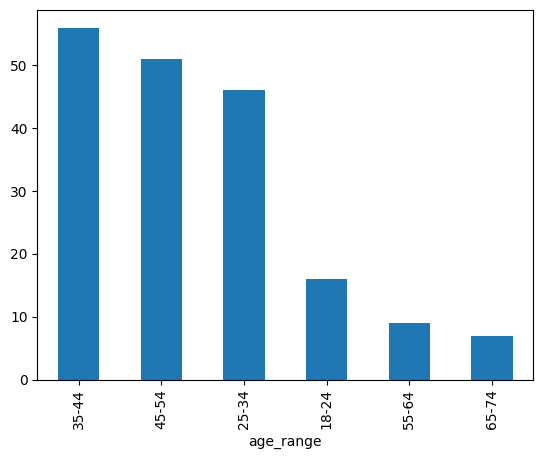

In [30]:
participants_df['age_range'].value_counts().plot(kind='bar')

***Age:*** Skewed towards 25-44 age group.

<Axes: xlabel='gender'>

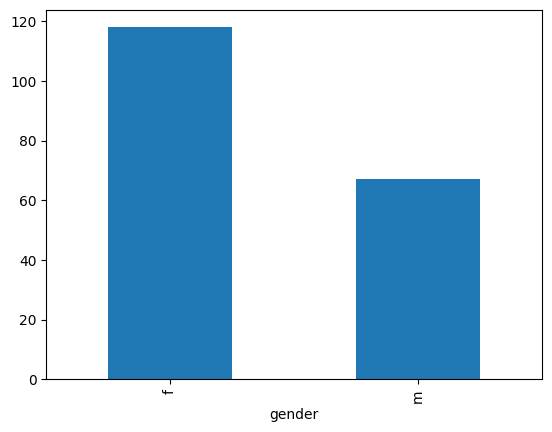

In [31]:
participants_df['gender'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

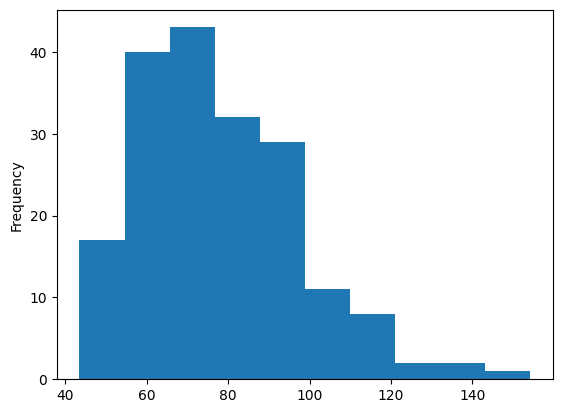

In [32]:
# We only care about weight because height isn't a major driving factor for hrv as weight is
participants_df['weight'].plot.hist()

***Weight:*** right-skewed

In [33]:
# Feature visualization for Sleep_df

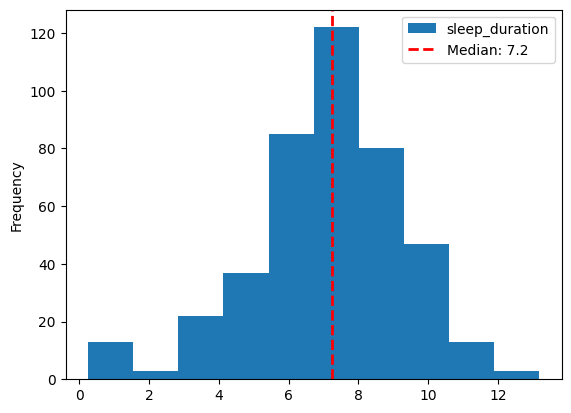

In [34]:
ax = sleep_df['sleep_duration'].plot.hist()
median_val = sleep_df['sleep_duration'].median()
# Add a vertical line for the median
ax.axvline(
    x=median_val, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Median: {median_val:.1f}'
)
plt.legend()

**Sleep duration:** centered around 7 hours (median line), roughly normal with some short outliers (likely naps or partial recordings).

In [35]:
sleep_df.dtypes

user_code                       object
day                     datetime64[ns]
sleep_begin             datetime64[ns]
sleep_end               datetime64[ns]
sleep_duration                 float64
sleep_awake_duration           float64
sleep_rem_duration             float64
sleep_light_duration           float64
sleep_deep_duration            float64
pulse_min                      float64
pulse_max                      float64
pulse_average                  float64
dtype: object

In [36]:
sleep_df.describe()

,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
count,425,425,425,425.000000,9.000000,7.000000,27.000000,14.000000,15.000000,15.000000,15.000000
mean,2020-03-10 09:15:40.235293952,2020-03-10 10:11:57.990588160,2020-03-10 17:20:17.722352896,7.138814,2733.333333,6518.571429,14514.740741,4280.285714,60.533333,89.866667,68.880733
min,2019-12-31 00:00:00,2019-12-31 05:50:00,2019-12-31 06:50:00,0.258333,1740.000000,2820.000000,300.000000,480.000000,52.000000,62.000000,59.444000
25%,2020-01-30 00:00:00,2020-01-29 23:40:00,2020-01-30 07:20:02,6.071389,2460.000000,5730.000000,7995.000000,2797.500000,54.500000,85.000000,63.393000
50%,2020-02-29 00:00:00,2020-02-29 00:14:04,2020-02-29 07:33:25,7.233611,2490.000000,6240.000000,17340.000000,4230.000000,58.000000,93.000000,65.857000
75%,2020-04-22 00:00:00,2020-04-22 00:23:22,2020-04-22 07:17:23,8.500000,2790.000000,8190.000000,20340.000000,5550.000000,60.000000,94.500000,70.250000
max,2020-06-17 00:00:00,2020-06-17 01:12:00,2020-06-17 08:14:00,13.183333,4200.000000,8730.000000,23100.000000,7934.000000,105.000000,105.000000,105.000000
std,NaN,NaN,NaN,2.159390,671.900290,2081.613385,8078.126290,2089.766547,12.844491,10.541528,10.947268


In [37]:
# Feature Visualizations for HRV_measurements

In [38]:
hrv_df.describe()

,measurement_datetime,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep
count,3245,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,1466.000000
mean,2020-04-21 08:42:40.999383552,73.257935,839.600366,0.184635,52.489218,52.814196,20.615609,0.837465,46.788290,927.038213,1125.041294,578.229892,2.397769,2630.309399,-0.235439,-0.076733,-0.065484
min,2019-12-31 06:08:29,44.000000,477.730000,0.030000,9.515000,6.340000,0.000000,0.475000,12.000000,2.000000,4.000000,1.000000,0.032000,44.000000,-2.000000,-2.000000,-2.000000
25%,2020-04-10 15:00:24,65.000000,742.490000,0.110000,32.585000,28.985000,6.060000,0.725000,35.000000,151.000000,158.000000,116.000000,0.399000,620.000000,-1.000000,0.000000,0.000000
50%,2020-05-01 07:47:14,72.000000,829.100000,0.160000,46.919000,42.869000,16.160000,0.825000,45.000000,423.000000,380.000000,293.000000,0.862000,1387.000000,0.000000,0.000000,0.000000
75%,2020-05-15 10:02:15,81.000000,925.933000,0.220000,64.406000,62.485000,29.290000,0.925000,57.000000,1059.000000,993.000000,693.000000,1.966000,2906.000000,0.000000,0.000000,0.000000
max,2020-06-19 11:40:13,125.000000,1346.740000,0.790000,206.631000,310.800000,91.920000,1.325000,98.000000,15522.000000,33490.000000,18468.000000,105.625000,41118.000000,2.000000,2.000000,2.000000
std,NaN,12.201088,137.420367,0.107456,29.369506,39.353213,18.588156,0.144769,16.418873,1455.424089,2490.540413,876.679652,5.750760,3912.247496,0.706262,0.655032,0.708656


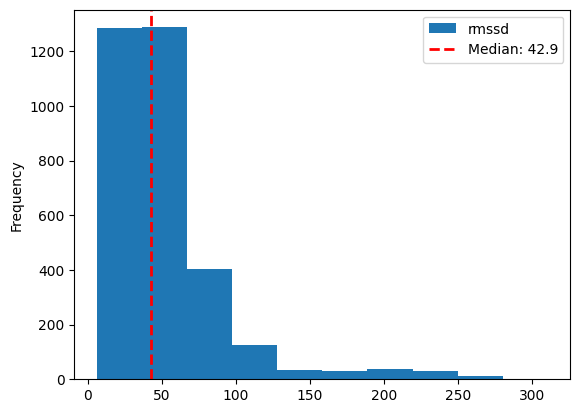

In [39]:
# We will be focusing only on the rmssd as that is the area of interest we are investigating.  We want to see how sleep duration
# affects rmssd in correlation with participant weight


# Data is skewed so will be using median as a reference
ax = hrv_df['rmssd'].plot.hist()

median_val_rmssd=hrv_df['rmssd'].median()
ax.axvline(
    x=median_val_rmssd, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Median: {median_val_rmssd:.1f}'
)
plt.legend()

**RMSSD:** heavily right-skewed with a long tail of high-RMSSD readings. Reinforces use of median (not mean) for aggregation.

In [107]:
# IQR outlier check on RMSSD
q1 = hrv_df['rmssd'].quantile(0.25)
q3 = hrv_df['rmssd'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr
outlier_count = ((hrv_df['rmssd'] < lower) | (hrv_df['rmssd'] > upper)).sum()
print(f'IQR bounds: {lower:.2f} to {upper:.2f} ms')
print(f'Outliers: {outlier_count} / {len(hrv_df)} ({outlier_count/len(hrv_df)*100:.1f}%)')
print(f'Median with outliers: {hrv_df["rmssd"].median():.2f}')
print(f'Median without outliers: {hrv_df.loc[(hrv_df["rmssd"] >= lower) & (hrv_df["rmssd"] <= upper), "rmssd"].median():.2f}')

IQR bounds: -21.27 to 112.73 ms
Outliers: 195 / 3245 (6.0%)
Median with outliers: 42.87
Median without outliers: 41.14


***Outlier decision:*** IQR flagged some RMSSD values as outliers, but the median barely shifts with or without them. Extreme RMSSD values are physiologically plausible (young/athletic individuals have high RMSSD, older/unwell individuals have low RMSSD), so keeping them to preserve signal.

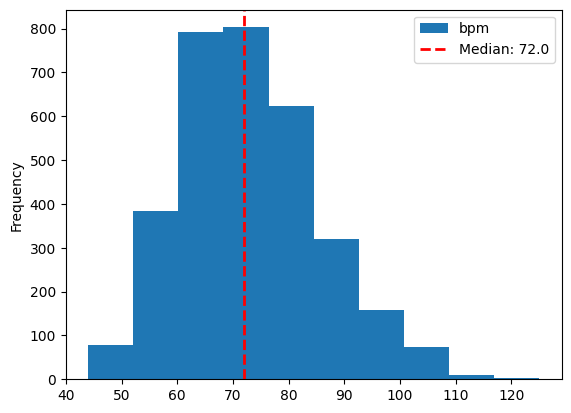

In [40]:
# BPM as well for sanity check

ax = hrv_df['bpm'].plot.hist()

median_val_bpm =hrv_df['bpm'].median()
ax.axvline(
    x=median_val_bpm, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Median: {median_val_bpm:.1f}'
)
plt.legend()

**BPM:** centered ~72 with a small right tail. All values within physiologically plausible bounds.

<Axes: xlabel='time_of_day'>

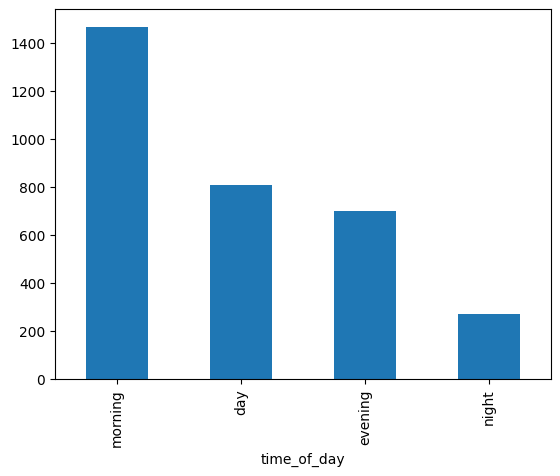

In [41]:
hrv_df['time_of_day'].value_counts().plot(kind='bar')

***Time_of_day:*** Seems most of the recordings are in the morning and day

<Axes: title={'center': 'rmssd'}, xlabel='time_of_day'>

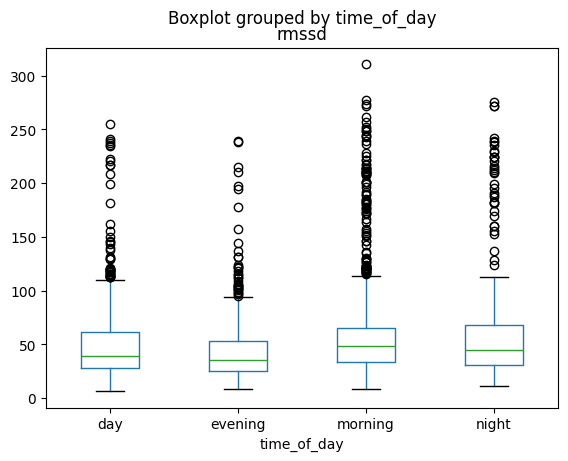

In [42]:
hrv_df.boxplot(column='rmssd', by='time_of_day', grid=False)

**Observation:** morning and night show slightly higher medians than day and evening — consistent with parasympathetic activity dominating during rest periods. The differences are modest, so **all readings will be used** with median aggregation (rather than filtering to morning only) to preserve sample size.

### Data Quality Checks - Duplicates  

In [44]:
# Data Quality for each of the three datasets
print("\nData Quality")
print("------------")
print(f"Participants Duplicated Rows: {participants_df.duplicated().sum()}")
print(f"HRV Measurements Duplicated Rows: {hrv_df.duplicated().sum()}")
print(f"Sleep Duplicated Rows: {sleep_df.duplicated().sum()}")



Data Quality
------------
Participants Duplicated Rows: 0
HRV Measurements Duplicated Rows: 0
Sleep Duplicated Rows: 0


In [45]:
print(f"participants: {participants_df.shape}")

print(f"hrv: {hrv_df.shape}")

print(f"sleep: {sleep_df.shape}")


participants: (185, 8)
hrv: (3245, 22)
sleep: (425, 12)


**No exact duplicate rows** found in any of the three datasets. No action required.

## Missing Values Strategy

Participants — height (2 nulls): Imputed with median. Added height_was_missing flag column for data lineage.

Participants — city, country, symptoms_onset: Left as-is. Not used in this analysis (focus is sleep vs RMSSD, 
not geographic or timeline analysis).

HRV — how_sleep, tags: Left as-is. Not used in this analysis (subjective/redundant with objective sleep data, unstructured text).

Sleep — awake/rem/light/deep duration, pulse: Left as-is. Scoped analysis to sleep_duration (the only sleep metric with adequate 
coverage — 100% vs <5% for others).

All variables of interest have zero nulls, so no imputation affects the final analysis.

### Height Imputation (Tracking which missing values I imputed)

In [46]:
participants_df['height_missing_flag'] = participants_df['height'].isnull()
participants_df['height_missing_flag']

0      False
1      False
2      False
3      False
4      False
       ...  
180    False
181    False
182    False
183    False
184    False
Name: height_missing_flag, Length: 185, dtype: bool

In [47]:
participants_df['height_missing_flag'].value_counts()

height_missing_flag
False    183
True       2
Name: count, dtype: int64

In [48]:
participants_df['height'] = participants_df['height'].fillna(participants_df['height'].median())
participants_df['height'].isnull().sum()

np.int64(0)

### Feature Engineering: BMI

**Rationale:** height and weight alone don't inform HRV as well as BMI does. BMI captures body composition — a known confounder for cardiac autonomic function. Engineering it here gives a single interpretable numeric feature that combines both.

In [49]:
# Converting height in cm to m to create BMI variable
participants_df['height_in_meters'] = participants_df['height']/100

In [50]:
participants_df['height_in_meters'].head()

0    1.7018
1    1.7400
2    1.7800
3    1.6900
4    1.5800
Name: height_in_meters, dtype: float64

In [51]:
# Feature Engineering - Creating BMI out of height and weight because BMI is a better measure that affects RMSSD than
# height and weight alone

In [53]:
participants_df['BMI'] = participants_df['weight']/participants_df['height_in_meters'] ** 2

In [54]:
participants_df['BMI'].head()

0    33.203698
1    25.531774
2    29.036738
3    21.007668
4    27.439513
Name: BMI, dtype: float64

### Data Transformations: Aggregating HRV to Daily Grain

HRV has multiple measurements per user per day; sleep has one row per user per night. To join them, HRV must be collapsed to one row per user per day.

**Aggregation choice: median RMSSD across all readings per (user, day).**
- **Median over mean:** RMSSD is right-skewed, so median is more robust to outliers.
- **All readings vs morning-only:** the time-of-day boxplot showed only modest differences, so all readings are used to preserve sample size.

In [55]:
hrv_df.head()

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


In [65]:
hrv_df['date'] = hrv_df['measurement_datetime'].dt.date

In [72]:
hrv_daily = hrv_df.groupby(['user_code', 'date'])['rmssd'].median().reset_index().sort_values('date')

In [73]:
hrv_daily

,user_code,date,rmssd
1459,cdfbcad405,2019-12-31,44.779
1682,fcf3ea75b0,2019-12-31,62.266
4,01bad5a519,2019-12-31,21.196
1460,cdfbcad405,2020-01-01,80.053
1321,b9b65b7a69,2020-01-01,31.199
...,...,...,...
469,403155ae59,2020-06-19,65.155
1861,fde84801d8,2020-06-19,26.404
1090,a1c2e6b2eb,2020-06-19,41.449
874,8011967ef0,2020-06-19,40.111


## 8. Joining the Datasets

**Two-step inner join:**
1. `sleep_df` + `hrv_daily` on `user_code` + `date` — pairs each night's sleep with that day's HRV summary.
2. Result + `participants_df` on `user_code` — attaches per-user confounders (age, gender, BMI).

**Inner join** used because a sleep row without matching HRV (or vice versa) can't contribute to the analysis.

In [106]:
sleep_df.head()

,user_code,date,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,0.000254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,0.001534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,0.001626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,0.002385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,0.002060,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


**Alignment step:** sleep uses `day`, HRV daily uses `date` — rename to match before merging.

In [77]:
sleep_df = sleep_df.rename(columns={'day':'date'})

In [81]:
sleep_df.dtypes

user_code                       object
date                    datetime64[ns]
sleep_begin             datetime64[ns]
sleep_end               datetime64[ns]
sleep_duration                 float64
sleep_awake_duration           float64
sleep_rem_duration             float64
sleep_light_duration           float64
sleep_deep_duration            float64
pulse_min                      float64
pulse_max                      float64
pulse_average                  float64
dtype: object

In [84]:
hrv_daily['date'] = pd.to_datetime(hrv_daily['date'])

In [85]:
hrv_daily.dtypes

user_code            object
date         datetime64[ns]
rmssd               float64
dtype: object

In [86]:
sleep_hrv = pd.merge(sleep_df, hrv_daily, on=['user_code','date'], how='inner')

In [89]:
participants_df.isnull().sum()

user_code               0
gender                  0
age_range               0
city                   12
country                 6
height                  0
weight                  0
symptoms_onset         38
height_missing_flag     0
height_in_meters        0
BMI                     0
dtype: int64

In [90]:
combined_df = pd.merge(sleep_hrv, participants_df, on=['user_code'], how='inner')

In [91]:
combined_df.head()

,user_code,date,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,...,gender,age_range,city,country,height,weight,symptoms_onset,height_missing_flag,height_in_meters,BMI
0,0d297d2410,2020-01-11,2020-01-11 01:00:10,2020-01-11 08:45:06,7.748889,NaN,NaN,23100.0,NaN,NaN,...,m,35-44,Moscow,Russia,173.0,86.0,NaT,False,1.73,28.734672
1,0d297d2410,2020-01-13,2020-01-13 01:15:00,2020-01-13 06:30:00,5.250000,NaN,NaN,NaN,NaN,NaN,...,m,35-44,Moscow,Russia,173.0,86.0,NaT,False,1.73,28.734672
2,0d297d2410,2020-02-13,2020-02-13 00:10:00,2020-02-13 06:55:11,6.753056,NaN,NaN,NaN,NaN,NaN,...,m,35-44,Moscow,Russia,173.0,86.0,NaT,False,1.73,28.734672
3,0d297d2410,2020-02-24,2020-02-24 00:56:06,2020-02-24 07:49:25,6.888611,NaN,NaN,NaN,NaN,NaN,...,m,35-44,Moscow,Russia,173.0,86.0,NaT,False,1.73,28.734672
4,0d297d2410,2020-03-13,2020-03-13 00:45:11,2020-03-13 06:55:07,6.165556,NaN,NaN,NaN,NaN,62.0,...,m,35-44,Moscow,Russia,173.0,86.0,NaT,False,1.73,28.734672


In [92]:
combined_df.shape

(110, 23)

***Observations:*** 110 rows now, small but sufficient for this EDA.  `

## Bivariate Exploration: Sleep Duration vs RMSSD

The primary question- does sleep duration relate to RMSSD in this dataset?

0.05634477513881987


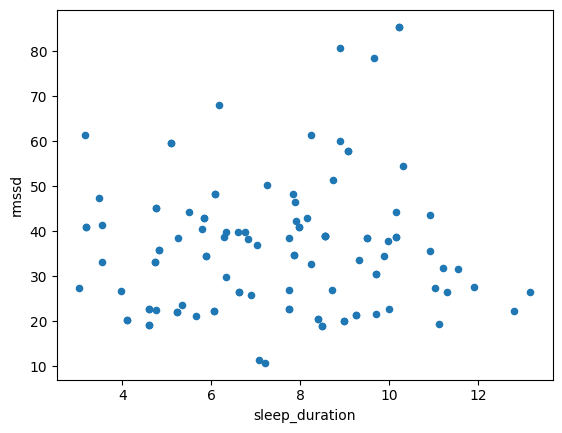

In [94]:
combined_df.plot.scatter(x='sleep_duration', y='rmssd')
print(combined_df['sleep_duration'].corr(combined_df['rmssd']))

In [95]:
print(combined_df['BMI'].corr(combined_df['rmssd']))

-0.1276254120729053


### Data Quality Assessment:

***Data profiling*** — Started by checking shapes, dtypes, nulls, and describe() on all three datasets. Spotted heavy nulls in the sleep dataset (deep, REM, light, awake all ~97% missing) and moderate nulls in participants (mostly in features I wasn't using like city, country, symptoms_onset). HRV had a lot of correlated metrics (SDNN, pnn50, LF, HF, etc.), so I scoped to RMSSD only to avoid multicollinearity.

***Completeness*** — Height had 2 nulls, imputed with median and added a height_missing_flag column to track it. Dropped how_sleep and other sparse fields from consideration. All variables actually used in the analysis ended up with zero nulls.

***Accuracy*** — Sleep duration was labeled as hours in the docs but the values were clearly too large (mean ~25,700). Confirmed it was seconds by checking one row against the sleep_begin/sleep_end timestamp delta. Converted to hours.

***Consistency*** — Converted all date/datetime fields from object to proper datetime types across datasets. Renamed sleep's day column to date so the merge with HRV daily worked cleanly. Standardized height to meters for the BMI calculation.

***Integrity*** — Ran duplicated().sum() on all three datasets, 0 duplicates in each. Join keys (user_code, date) verified before merging.

***Lineage & Provenance*** — Data pulled from the Welltory hrv-covid19 GitHub repo. Imputation tracked via the height_missing_flag column so it's clear which rows were touched.

### Summary & Limitations

### Summary

The question was: how do sleep duration and BMI relate to RMSSD?

The scatter and correlation showed essentially no linear relationship between sleep duration and RMSSD (0.06). This might be because sleep duration alone doesn't capture sleep quality. 8 hours of bad sleep and 8 hours of good sleep look identical in this data, but they'd affect recovery very differently. BMI showed a weak negative correlation with RMSSD (-0.128), which is in the physiologically expected direction (lower BMI tends toward higher RMSSD, meaning better recovery capacity).

So sleep duration alone isn't a strong marker for RMSSD in this dataset. BMI is a slightly better signal but still weak.

### Limitations

* Sample size after the inner join was only 110 rows, which limits how much any correlation can be trusted.
* Most of the sleep quality features (deep, REM, light, awake) were ~97% missing, so I couldn't use the metrics that actually capture sleep quality.
* All participants were COVID positive, and symptom severity wasn't controlled for. Being sick affects RMSSD more than sleep duration does, so that's likely adding noise.
* The analysis is between subject rather than within subject, so I can't isolate how one person's sleep affects their own RMSSD over time.
* HRV was aggregated to a daily median, which may hide time of day effects.

### Future Work

Incorporating symptom severity from the surveys data could reveal patterns tied to where each participant is in their COVID timeline. A within subject longitudinal analysis would also be more informative than the aggregate view here.